# LIBERO 环境创建演示

这个 notebook 演示了如何：
1. 加载和解析 BDDL 文件
2. 修改 `parsed_problem` 中的物体位置
3. **从修改后的 `parsed_problem` 直接创建环境** (NEW!)

详细文档请参考：`HOW_TO_CREATE_ENV_FROM_PARSED_PROBLEM.md`


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from libero.libero import benchmark
from libero.libero.envs import OffScreenRenderEnv
import os
from libero.libero import get_libero_path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import libero.libero.envs.bddl_utils as BDDLUtils
import tempfile
from libero.libero.envs.bddl_utils import generate_bddl_from_parsed_problem
from utils_displacement import modify_object_region_position, get_libero_image

11111111111111111111111


[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /hdd/zijianwang/openpi/examples/libero/.venv/lib/python3.8/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)


/hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/./bddl_files/libero_10/LIVING_ROOM_SCENE2_put_both_the_alphabet_soup_and_the_tomato_sauce_in_the_basket.bddl
libero_10


In [3]:
benchmark_dict = benchmark.get_benchmark_dict()
task_suite_name = "libero_10" # can also choose libero_spatial, libero_object, etc.
task_suite = benchmark_dict[task_suite_name]()

# retrieve a specific task
task_id = 0
task = task_suite.get_task(task_id)
task_name = task.name
task_description = task.language
task_bddl_file = os.path.join(get_libero_path("bddl_files"), task.problem_folder, task.bddl_file)


## bbdl文件名称主要在LIBERO-PRO/libero/libero/benchmark/libero_suite_task_map.py中定义
print(f"[info] retrieving task {task_id} from suite {task_suite_name}, the " + \
      f"language instruction is {task_description},\n and the bddl file is {task_bddl_file}")

# step over the environment
env_args = {
    "bddl_file_name": task_bddl_file,
    "camera_heights": 256,
    "camera_widths": 256
}
env = OffScreenRenderEnv(**env_args)
print(f"All object names: {list(env.env.objects_dict.keys())}")
print(f"Obj of interest: {env.env.obj_of_interest}")
env.seed(0)
env.reset()
# init_states = task_suite.get_task_init_states(task_id) # for benchmarking purpose, we fix the a set of initial states
# init_state_id = 0
# env.set_init_state(init_states[init_state_id])

dummy_action = [0.] * 7
for step in range(10):
    obs, reward, done, info = env.step(dummy_action)
env.close()

print("✓ Demo completed successfully!")

[info] Applying task order index 0 (permutation: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) for benchmark 'libero_10' (10 tasks).
[Warning]: datasets path /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/../datasets does not exist!
[info] retrieving task 0 from suite libero_10, the language instruction is put both the alphabet soup and the tomato sauce in the basket,
 and the bddl file is /hdd/zijianwang/openpi/third_party/LIBERO-PRO/libero/libero/./bddl_files/libero_10/LIVING_ROOM_SCENE2_put_both_the_alphabet_soup_and_the_tomato_sauce_in_the_basket.bddl


/hdd/zijianwang/openpi/examples/libero/.venv/lib/python3.8/site-packages/numba/np/arraymath.py:3845: DeprecationWarning: `np.MachAr` is deprecated (NumPy 1.22).
  @overload(np.MachAr)


All object names: ['alphabet_soup_1', 'cream_cheese_1', 'tomato_sauce_1', 'ketchup_1', 'orange_juice_1', 'milk_1', 'butter_1', 'basket_1']
Obj of interest: ['alphabet_soup_1', 'tomato_sauce_1', 'basket_1']
✓ Demo completed successfully!


In [4]:
parsed_problem = BDDLUtils.robosuite_parse_problem(task_bddl_file)

# 示例使用
new_parsed_problem = modify_object_region_position(parsed_problem, "alphabet_soup_1", "y", 0.1)
## x方向控制上下,正往下走, 负往上走
## y方向控制左右,正往左走, 负往右走
# new_parsed_problem = modify_object_region_position(parsed_problem, "alphabet_soup_1", "x", [0.2, 0.2])


Old ranges: [[-0.125, -0.175, -0.07500000000000001, -0.125]]
Successfully modified region 'living_room_table_alphabet_soup_init_region' for object 'alphabet_soup_1'
New ranges: [[-0.125, -0.07499999999999998, -0.07500000000000001, -0.024999999999999994]]


比较原始环境 vs 修改后的环境


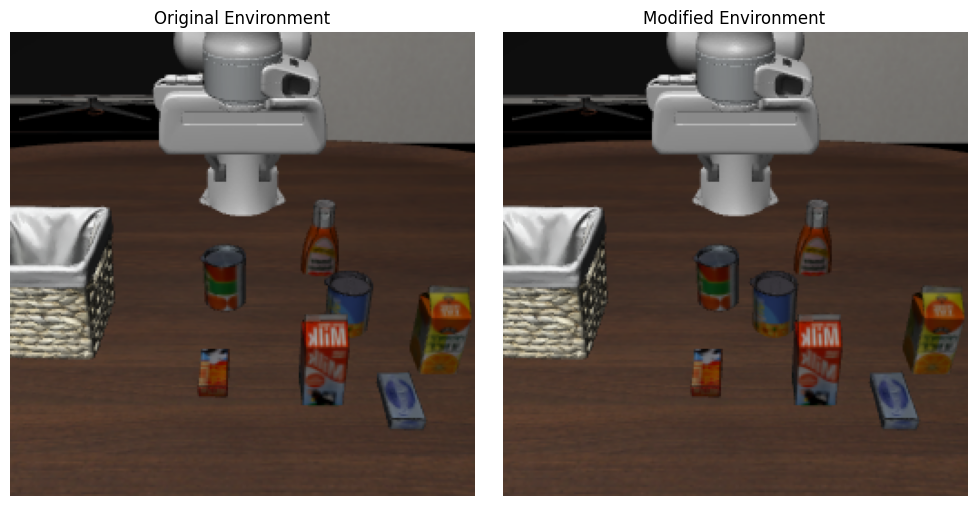


✓ 对比完成！你可以看到 basket 的位置已经改变了。


In [5]:
# 完整示例：比较原始环境和修改后的环境
print("=" * 70)
print("比较原始环境 vs 修改后的环境")
print("=" * 70)

# 1. 创建原始环境
env_original = OffScreenRenderEnv(
    bddl_file_name=task_bddl_file,
    camera_heights=256,
    camera_widths=256
)

env_original.seed(0)
obs_original = env_original.reset()
img_original = get_libero_image(obs_original, 224)

# 2. 创建修改后的环境（basket 位置改变）


# env_modified = BDDLUtils.create_env_from_parsed_problem(
#     new_parsed_problem,
#     camera_heights=256,
#     camera_widths=256
# )
new_task_bddl_content = generate_bddl_from_parsed_problem(new_parsed_problem)
with tempfile.NamedTemporaryFile(mode='w', suffix='.bddl', delete=False) as f:
    f.write(new_task_bddl_content)
    new_task_bddl_file = f.name
env_modified = OffScreenRenderEnv(
    bddl_file_name=new_task_bddl_file,
    camera_heights=256,
    camera_widths=256
)
env_modified.seed(0)
obs_modified = env_modified.reset()
img_modified = get_libero_image(obs_modified, 224)

# 3. 并排显示对比
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_original)
axes[0].set_title("Original Environment")
axes[0].axis('off')

axes[1].imshow(img_modified)
axes[1].set_title("Modified Environment")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 清理
env_original.close()
env_modified.close()

print("\n✓ 对比完成！你可以看到 basket 的位置已经改变了。")


In [7]:
print(parsed_problem.keys())
print(parsed_problem["objects"])
print(parsed_problem["regions"])
print("initial_state:", parsed_problem["initial_state"])
print(parsed_problem["obj_of_interest"])

dict_keys(['problem_name', 'fixtures', 'regions', 'objects', 'scene_properties', 'initial_state', 'goal_state', 'language_instruction', 'obj_of_interest'])
{'alphabet_soup': ['alphabet_soup_1'], 'basket': ['basket_1'], 'salad_dressing': ['salad_dressing_1'], 'cream_cheese': ['cream_cheese_1'], 'milk': ['milk_1'], 'tomato_sauce': ['tomato_sauce_1'], 'butter': ['butter_1'], 'akita_black_bowl': ['akita_black_bowl_1']}
{'floor_bin_region': {'target': 'floor', 'ranges': [[-0.01, 0.25, 0.01, 0.27]], 'extra': [], 'yaw_rotation': [0.0, 0.0], 'rgba': [0, 0, 1, 0]}, 'floor_target_object_region': {'target': 'floor', 'ranges': [[0.05500000000000002, -0.065, 0.10500000000000001, -0.014999999999999986]], 'extra': [], 'yaw_rotation': [0.0, 0.0], 'rgba': [0, 0, 1, 0]}, 'floor_other_object_region_0': {'target': 'floor', 'ranges': [[0.024999999999999998, -0.125, 0.07500000000000001, -0.075]], 'extra': [], 'yaw_rotation': [0.0, 0.0], 'rgba': [0, 0, 1, 0]}, 'floor_other_object_region_1': {'target': 'floor

In [ ]:
# 可选：查看生成的 BDDL 内容（用于调试和验证）
bddl_content = BDDLUtils.generate_bddl_from_parsed_problem(new_parsed_problem)

print("生成的 BDDL 内容 (部分):")
print("=" * 60)
# 只显示前 50 行
lines = bddl_content.split('\n')
for i, line in enumerate(lines[:50]):
    print(f"{i+1:3d}: {line}")
if len(lines) > 50:
    print(f"... (还有 {len(lines) - 50} 行)")
print("=" * 60)
